[Decoded(data=b'EP-T2510NBEGUS+RF7Y5HMPL32DKB', rect=Rect(left=8, top=8, width=82, height=81))]


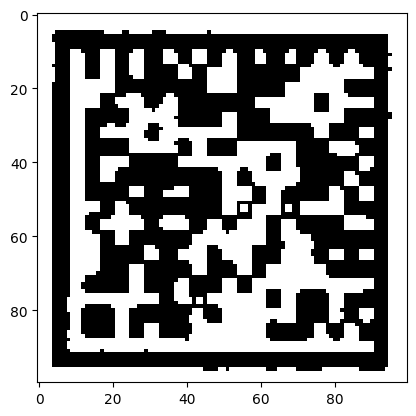

[Decoded(data=b'EP-T2510NBEGUS+RF7Y5HMPL32DKB', rect=Rect(left=8, top=9, width=83, height=80))]


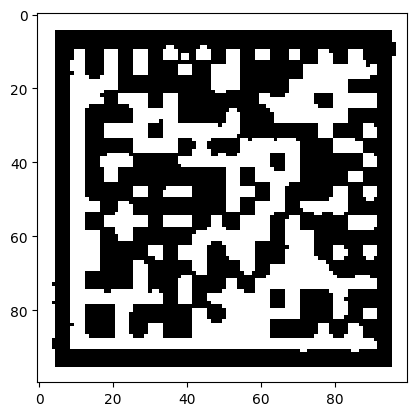

[Decoded(data=b'EP-T2510NBEGUS+RF7Y42T12Q2DKB', rect=Rect(left=10, top=8, width=81, height=80))]


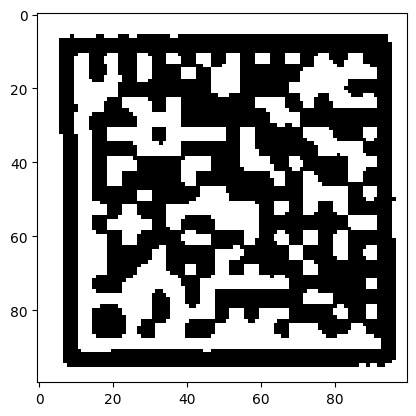

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pylibdmtx.pylibdmtx import decode

# --- SETUP ---
input_folder = r"qr"
output_folder = r"qr_cropped"
os.makedirs(output_folder, exist_ok=True)

# --- PROCESS ---
for filename in os.listdir(input_folder):
    if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
        img_path = os.path.join(input_folder, filename)
        image = cv2.imread(img_path)
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        # smooth = cv2.bilateralFilter(gray, d=9, sigmaColor=75, sigmaSpace=75)
        # enhanced = cv2.equalizeHist(smooth)
        
        ret, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_OTSU + cv2.THRESH_BINARY_INV)
        contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        for cnt in contours:
            epsilon = 0.02 * cv2.arcLength(cnt, True)
            approx = cv2.approxPolyDP(cnt, epsilon, True)

            if len(approx) == 4:
                # Order points
                pts = approx.reshape(4, 2).astype(np.float32)

                def order_points(pts):
                    rect = np.zeros((4, 2), dtype="float32")
                    s = pts.sum(axis=1)
                    rect[0] = pts[np.argmin(s)]
                    rect[2] = pts[np.argmax(s)]

                    diff = np.diff(pts, axis=1)
                    rect[1] = pts[np.argmin(diff)]
                    rect[3] = pts[np.argmax(diff)]
                    return rect

                rect = order_points(pts)
                dst = np.array([
                    [0, 0],
                    [100 - 1, 0],
                    [100 - 1, 100 - 1],
                    [0, 100 - 1]
                ], dtype="float32")

                M = cv2.getPerspectiveTransform(rect, dst)
                warped = cv2.warpPerspective(image, M, (100, 100))
                gray_warped = cv2.cvtColor(warped, cv2.COLOR_BGR2GRAY)
                # 1. Apply CLAHE (improve local contrast)
                clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
                enhanced = clahe.apply(gray_warped)

                # 2. Use Otsu thresholding (less aggressive than adaptive)
                _, thresh = cv2.threshold(enhanced, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

                # 3. Very light dilation to connect thin lines without removing details
                kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2))  # smaller kernel
                morphed = cv2.dilate(thresh, kernel, iterations=1)
                decoded = decode(morphed, max_count=1)
                print(decoded)
        plt.imshow(morphed, cmap='gray')
        plt.show()